In [17]:
import time
import matplotlib.pyplot as plt
import numpy as np
import os
import heapq
import signal

In [18]:
class TreeNode:
    def __init__(self, level, V, W, taken, upper_bound=None):
        self.level = level  # niveau dans l’arbre de recherche >=0
        self.V = V  # valeur de la solution courante
        self.W = W  # poids de la solution courante
        self.taken = taken  # liste des index d’objets de la solution courante
        self.upper_bound = upper_bound  # Upper Bound of the solution (for Best First method)

    def __lt__(self, other):
        return (self.upper_bound or 0) > (other.upper_bound or 0)  # Highest bound has priority
    

class KPBB_BestFirst:
    def __init__(self, values, weights, cap): 
        self.capacity = cap
        self.values = values
        self.weights = weights
        self.unordered = [((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))]
        self.ordered = sorted([((v, w), i) for i, (v, w) in enumerate(zip(self.values, self.weights))], key=lambda tup: float(tup[0][0])/tup[0][1], reverse=True)
    
    def UpperBound(self, node): # calcul UpperBound
        W = self.capacity - node.W # remaining capacity
        result = node.V
        i = node.level + 1 # next level
        
        while i < len(self.ordered) and self.ordered[i][0][1] <= W: # while there are itens left and it fits
            W -= self.ordered[i][0][1] # reduces capacity
            result += self.ordered[i][0][0] # ads it to the sac a dos
            i += 1 # goes to next item
        
        if i < len(self.ordered): # when no more itens fits, ads a fraction of the following item
            result += self.ordered[i][0][0] * (W / self.ordered[i][0][1]) 
        return result

    def solve(self):
        root = TreeNode(-1, 0, 0, [], self.UpperBound(TreeNode(-1, 0, 0, [], 0)))  # root node
        queue = []
        heapq.heappush(queue, root)

        self.bestValue = 0
        self.bestTaken = []

        self.n_it = 0

        while queue:
            node = heapq.heappop(queue)
            self.n_it = self.n_it + 1

            if node.upper_bound <= self.bestValue:
                continue  # Cuts the node

            if node.level < len(self.ordered) - 1:
                # Caso 1: Incluir o item
                item = self.ordered[node.level + 1]
                nodeRight = TreeNode(node.level + 1, node.V + item[0][0], node.W + item[0][1], node.taken + [item[1]], self.UpperBound(node))
                
                if nodeRight.W <= self.capacity and nodeRight.V > self.bestValue:
                    self.bestValue = nodeRight.V
                    self.bestTaken = nodeRight.taken

                if nodeRight.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeRight)

                # Caso 2: Não incluir o item
                nodeLeft = TreeNode(node.level + 1, node.V, node.W, node.taken, self.UpperBound(node))
                
                if nodeLeft.upper_bound > self.bestValue:
                    heapq.heappush(queue, nodeLeft)

        return self.bestValue, self.bestTaken, self.n_it    
    
    
def knapsack_BU(values, weights, W):
    W = int(W) 
    n = len(values) 

    dp = [[0] * (W + 1) for _ in range(n + 1)] # Zero Matrix with (n+1) rows and (W+1) columns 
    n_it = 0

    for i in range(n): # for each item 
        n_it = n_it + 1
        wi = int(weights[i]) 

        for x in range(W + 1):  # Cycle through all possible backpack capacities
            # If you don't get the current item
            dp[i + 1][x] = dp[i][x]

            #  Possibility 2: take the item 
            if wi <= x: # checks if it fits in the backpack
                dp[i + 1][x] = max(dp[i + 1][x], values[i] + dp[i][x - wi])

    # The maximum possible value is in the last cell of the matrix
    return dp[n][W], n_it 

## Exercice 1 – Recuit simulé pour le problème du sac à dos 0/1

On vous demande dans cet exercice de programmer un algorithme de recuit simulé pour résoudre le problème
du sac à dos 0/1. Vous testerez votre algorithme sur les données fournies lors des séances précédentes. Vous
comparerez statistiquement (donc en faisant de multiples run de votre algorithme, ce qui est indispensable
quand l’aléatoire intervient) les résultats de votre algorithme avec ceux obtenus par une stratégie déterministe,
consistant à accepter uniquement les solutions améliorantes. Vous pourrez également :

- comparer les solutions obtenues avec les solutions optimales.
- analyser l’impact des différents paramètres de l’algorithme.

Pour générer un voisin à partir d’une solution initiale, plusieurs options pourront être imaginées. Une pos-
sibilité consiste à :

1. Tirer aléatoirement un objet non présent dans le sac
2. Ajouter cet objet
3. Tant que le poids du sac dépasse la capacité maximale :

(a) Tirer aléatoirement un objet présent dans le sac

(b) Supprimer cet objet

In [ ]:
def initial_solution(weights, values, wmax): # generates a inicial solution
    n = len(weights)
    selected = np.zeros(n, dtype=int) # list of selected itens
    W = wmax
    result = 0

    indices = np.random.permutation(n)  # Shuffle ids to have a random start

    for i in indices: # fills the knapsack 
        if W >= weights[i]:
            selected[i] = 1
            W -= weights[i]
            result += values[i]

    return selected, result, W # returns a random start

def knapsack_value(selected, weights, values): # calculates the value and weight of a knapsack
    value = np.dot(selected, values)
    weight = np.dot(selected, weights)
    return value, weight

def get_neighbor(selected, weights, values, wmax): # modifies an item to generate a neighbor
    neighbor = selected.copy()
    n = len(weights)

    i = np.random.randint(n) #picks a random item
    neighbor[i] = 1 - neighbor[i]  # adds or removes the item

    new_value, new_weight = knapsack_value(neighbor, weights, values) # calculates the new value and weight

    if new_weight > wmax: # if it doesnt fit
        neighbor[i] = selected[i]  # changes back
        new_value, new_weight = knapsack_value(neighbor, weights, values)

    return neighbor, new_value, new_weight # returns the neighbor

def simulated_annealing_knapsack(values, weights, wmax, T0=100, coeff=0.99, iter_step=100, stop_threshold=0.001):
    current_solution, current_value, current_weight = initial_solution(weights, values, wmax) # generates random initial solution
    best_solution = current_solution.copy()
    best_value = current_value
    T = T0 # initial temperature
    n_it = 0

    while T > stop_threshold: # while ther is still temperarure
        n_it = n_it +1
        nb_moves = 0
        for i in range(iter_step):
            # Generates a neighbor
            new_solution, new_value, new_weight = get_neighbor(current_solution, weights, values, wmax)
            
            # calculates
            delta = new_value - current_value

            # Critério de Metropolis
            if delta > 0 or np.random.rand() < np.exp(delta / T):
                current_solution = new_solution.copy()
                current_value = new_value
                current_weight = new_weight
                nb_moves += 1

                # Atualiza melhor solução encontrada
                if current_value > best_value:
                    best_solution = current_solution.copy()
                    best_value = current_value

        # Atualiza a temperatura
        acceptance_rate = nb_moves / iter_step if iter_step > 0 else 0
        if acceptance_rate < stop_threshold:
            break  # Critério de parada se a aceitação for muito baixa
        T *= coeff

    return best_solution, best_value, n_it


### Single Test

In [20]:
path = "./instances_01_KP/low-dimensional/f10_l-d_kp_20_879" 
dataset = np.loadtxt(path)

n = int(dataset[0][0])
wmax = dataset[0][1]
itens = dataset[1:]

weights = dataset[1:,1]
values = dataset[1:,0]

print(weights)
print(values)

[84. 83. 43.  4. 44.  6. 82. 92. 25. 83. 56. 18. 58. 14. 48. 70. 96. 32.
 68. 92.]
[91. 72. 90. 46. 55.  8. 35. 75. 61. 15. 77. 40. 63. 75. 29. 75. 17. 78.
 40. 44.]


In [21]:
methods = {
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    "B&B Best First": KPBB_BestFirst
}

times = {method: [] for method in methods}
n_values = []

for method_name, method in methods.items():
    tic = time.perf_counter()

    if method_name == "Simulated Annealing":
        bestTaken, bestValue, n_it = method(values, weights, wmax)  
        print("Estimated Best value:", bestValue)
    elif method_name == "Bottom-Up":
        bestValue, n_it = method(values, weights, wmax)  
        print("Optimal value:", bestValue)
        bestTaken = None
    else:
        knapsack_solver = method(values, weights, wmax)
        print("Chosen itens:", bestTaken)
        bestValue, bestTaken, n_it = knapsack_solver.solve()

    toc = time.perf_counter()
    times[method_name].append(toc - tic)
    print(f"{method_name} = {(toc - tic):.4}s")
    print(n_it, "iteraions \n")

n_values.append(n)

Estimated Best value: 1025.0
Simulated Annealing = 0.4962s
1146 iteraions 

Optimal value: 1025.0
Bottom-Up = 0.004487s
20 iteraions 

Chosen itens: None
B&B Best First = 0.0005057s
121 iteraions 



### Low Dimensional

In [22]:
datasets = []
listing = os.listdir("./instances_01_KP/low-dimensional/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    path = "./instances_01_KP/low-dimensional/" + infile
    data = np.loadtxt(path)
    datasets.append(data)


=== Problem with 15 items and 375 capacity ===
Estimated Best value: 481.06936799999994
Simulated Annealing = 0.53s
1146 iteraions 

Optimal value: 481.069368
Bottom-Up = 0.001287s
15 iteraions 

Chosen itens: [11, 7, 10, 6, 2, 4, 14, 13, 9]
B&B Best First = 0.0003537s
157 iteraions 


=== Problem with 10 items and 269 capacity ===
Estimated Best value: 295.0
Simulated Annealing = 0.5033s
1146 iteraions 

Optimal value: 295.0
Bottom-Up = 0.0005697s
10 iteraions 

Chosen itens: [1, 9, 8, 7, 2, 3]
B&B Best First = 0.0003937s
193 iteraions 


=== Problem with 10 items and 60 capacity ===
Estimated Best value: 52.0
Simulated Annealing = 0.5036s
1146 iteraions 

Optimal value: 52.0
Bottom-Up = 0.0001475s
10 iteraions 

Chosen itens: [7, 6, 8, 9, 5, 4, 2]
B&B Best First = 0.001217s
527 iteraions 


=== Problem with 20 items and 878 capacity ===
Estimated Best value: 1024.0
Simulated Annealing = 0.4579s
1146 iteraions 

Optimal value: 1024.0
Bottom-Up = 0.004295s
20 iteraions 

Chosen itens:

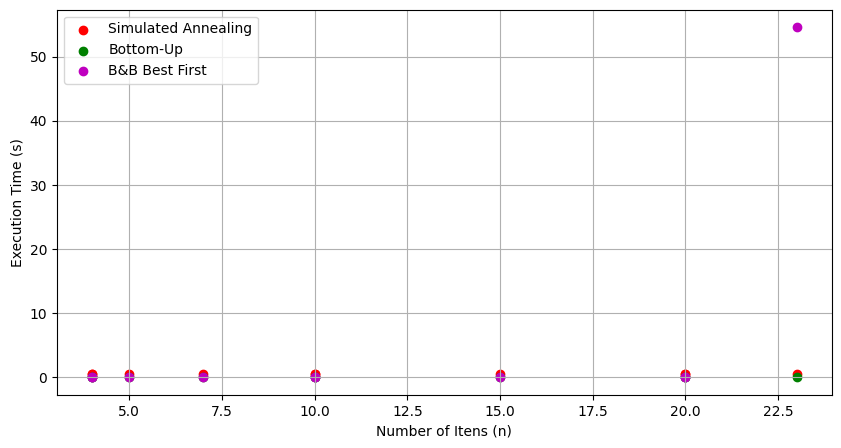

In [23]:
methods = {
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    "B&B Best First": KPBB_BestFirst
}

times = {method: [] for method in methods}
n_values = []


for dataset in datasets:
    n = int(dataset[0][0])
    wmax = dataset[0][1] 
    itens = dataset[1:]
    weights = dataset[1:, 1]
    values = dataset[1:, 0]

    print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")

    for method_name, method in methods.items():
        tic = time.perf_counter()

        if method_name == "Simulated Annealing":
            bestTaken, bestValue, n_it = method(values, weights, wmax)  
            print("Estimated Best value:", bestValue)
        elif method_name == "Bottom-Up":
            bestValue, n_it = method(values, weights, wmax)  
            print("Optimal value:", bestValue)
            bestTaken = None
        else:
            knapsack_solver = method(values, weights, wmax)
            bestValue, bestTaken, n_it = knapsack_solver.solve()
            print("Chosen itens:", bestTaken)

        toc = time.perf_counter()
        times[method_name].append(toc - tic)
        print(f"{method_name} = {(toc - tic):.4}s")
        print(n_it, "iteraions \n")

    n_values.append(n)
    
# Plot exec times
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    We can again see the effect of a high knapsack capacity value impacting the data visualization.
  </p>
</div>

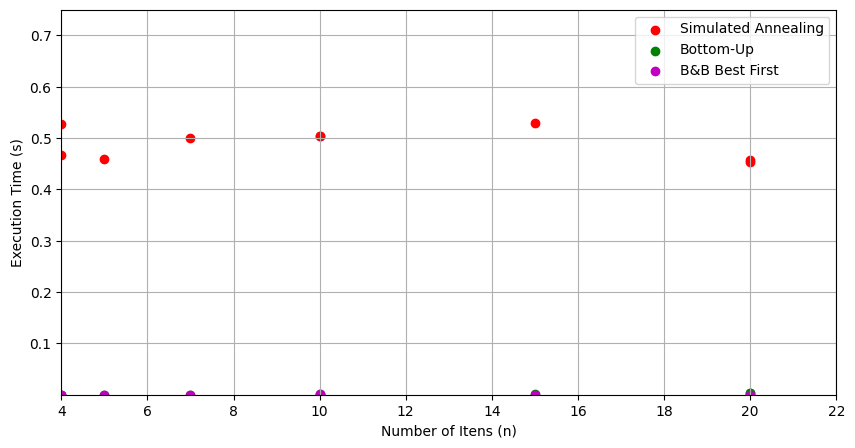

In [24]:
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlim([min(n_values), 22.0])  
plt.ylim([min(method_times), 0.75])  
plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    The Simulated Annealing method proved to be less efficient in the Low Dimensional examples, as the number of iterations required to meet the stopping criterion is large compared to the other methods. It is also important to mention its accuracy: only one trial did not produce an estimated result equal to the optimal result (though it was still a close result), which is very good for a non-exact method.
  </p>
</div>

#### Large Scale

In [25]:
datasets = []
N_values = []
W_values = []
listing = os.listdir("./instances_01_KP/large_scale/")
my_array=np.zeros(shape=(0,5))
for infile in listing:
    print(infile)
    path = os.path.join("./instances_01_KP/large_scale/", infile)
    # path = os.path.join("./instances_01_KP/large_scale/knapPI_1_200_1000_1")
    
    parts = infile.split("_")
    N = int(parts[2])  
    W = int(parts[3])  
    
    N_values.append(N)
    W_values.append(W)

    with open(path, "r") as f:
        lines = f.readlines()[:-1]  
    
    data = np.loadtxt(lines)
    datasets.append(data)
    # break

knapPI_1_200_1000_1
knapPI_3_2000_1000_1
knapPI_3_1000_1000_1
knapPI_2_200_1000_1
knapPI_3_5000_1000_1
knapPI_2_1000_1000_1
knapPI_3_500_1000_1
knapPI_2_5000_1000_1
knapPI_3_100_1000_1
knapPI_1_2000_1000_1
knapPI_3_200_1000_1
knapPI_2_10000_1000_1
knapPI_1_10000_1000_1
knapPI_1_500_1000_1
knapPI_2_2000_1000_1
knapPI_1_5000_1000_1
knapPI_2_100_1000_1
knapPI_2_500_1000_1
knapPI_1_100_1000_1
knapPI_1_1000_1000_1
knapPI_3_10000_1000_1


In [26]:
def timeout_handler(num, stack):
    raise Exception("Timeout")

methods = {
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    # "B&B Best First": KPBB_BestFirst
}

# Dic to store exec times
times = {method: [] for method in methods}
n_values = []

for dataset in datasets:
    n = dataset[0][0] 
    wmax = dataset[0][1]
    itens = dataset[1:]
    weights = dataset[1:, 1]
    values = dataset[1:, 0]

    print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")
    
    for method_name, method in methods.items():
        tic = time.perf_counter()

        if method_name == "Bottom-Up":
            bestValue, n_it = method(values, weights, wmax)  
            print(f"{method_name}, Optimal value:", bestValue)
            bestTaken = None
        else:
            bestTaken, bestValue, n_it = method(values, weights, wmax)  
            print(f"{method_name}, Estimated Best value:", bestValue)

        toc = time.perf_counter()
        times[method_name].append(toc - tic)
        print(f"{(toc - tic):.4f}s, {n_it} iterations")

    n_values.append(n)
    


=== Problem with 200 items and 1008 capacity ===
Simulated Annealing, Estimated Best value: 4878.0
0.7280s, 1146 iterations
Bottom-Up, Optimal value: 11238.0
0.0306s, 200 iterations

=== Problem with 2000 items and 9819 capacity ===
Simulated Annealing, Estimated Best value: 12917.0
1.2360s, 1146 iterations
Bottom-Up, Optimal value: 28919.0
4.9757s, 2000 iterations

=== Problem with 1000 items and 4990 capacity ===
Simulated Annealing, Estimated Best value: 6590.0
0.9671s, 1146 iterations
Bottom-Up, Optimal value: 14390.0
1.2206s, 1000 iterations

=== Problem with 200 items and 1008 capacity ===
Simulated Annealing, Estimated Best value: 1265.0
0.6896s, 1146 iterations
Bottom-Up, Optimal value: 1634.0
0.0299s, 200 iterations

=== Problem with 5000 items and 24805 capacity ===
Simulated Annealing, Estimated Best value: 30905.0
2.1028s, 1146 iterations
Bottom-Up, Optimal value: 72505.0
32.6322s, 5000 iterations

=== Problem with 1000 items and 5002 capacity ===
Simulated Annealing, Esti

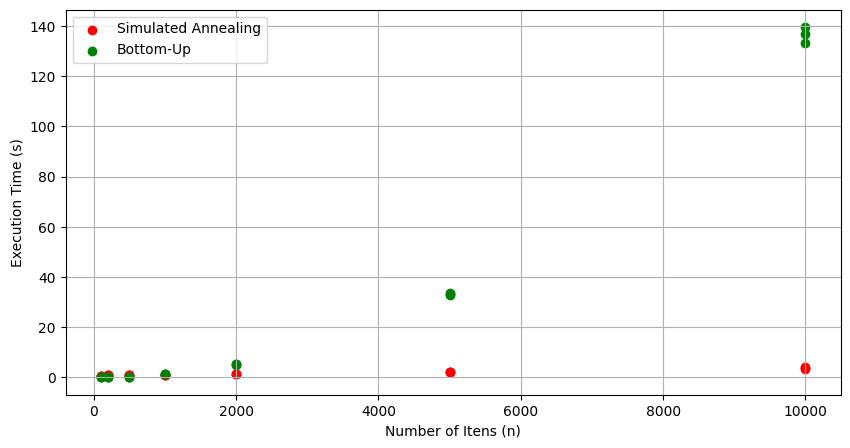

In [23]:
# Plot exec times
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    For the Large Scale examples, the speed of the Simulated Annealing method was slower than the Bottom-Up method starting from 1000 items in the knapsack, as the number of iterations for BU equals the number of items, while the iterations for SA always stay within the same range. However, the estimated results were far from the optimal value, which is unsatisfactory. This may have occurred because the number of items explored is small compared to the number of available items, as the temperature drops too quickly.
  </p>
</div>

In [27]:
def get_neighbor(selected, weights, values, wmax):
    """Gera um vizinho trocando múltiplos itens com baixa probabilidade."""
    neighbor = selected.copy()
    n = len(weights)
    
    # Probabilidade de trocar mais de um item em problemas grandes
    num_changes = 1 if n < 50 else np.random.randint(1, min(5, n // 10))  

    for _ in range(num_changes):
        i = np.random.randint(n)
        neighbor[i] = 1 - neighbor[i]  # Alterna 0/1

    new_value, new_weight = knapsack_value(neighbor, weights, values)

    # Se ultrapassar o peso máximo, reverte as mudanças
    if new_weight > wmax:
        neighbor = selected.copy()
        new_value, new_weight = knapsack_value(neighbor, weights, values)

    return neighbor, new_value, new_weight


In [28]:
def timeout_handler(num, stack):
    raise Exception("Timeout")

methods = {
    "Simulated Annealing" : simulated_annealing_knapsack,
    "Bottom-Up": knapsack_BU,
    # "B&B Best First": KPBB_BestFirst
}

# Dic to store exec times
times = {method: [] for method in methods}
n_values = []

for dataset in datasets:
    n = dataset[0][0] 
    wmax = dataset[0][1]
    itens = dataset[1:]
    weights = dataset[1:, 1]
    values = dataset[1:, 0]

    print(f"\n=== Problem with {n:.0f} items and {wmax:.0f} capacity ===")
    
    for method_name, method in methods.items():
        tic = time.perf_counter()

        if method_name == "Bottom-Up":
            bestValue, n_it = method(values, weights, wmax)  
            print(f"{method_name}, Optimal value:", bestValue)
            bestTaken = None
        else:
            bestTaken, bestValue, n_it = method(values, weights, wmax)  
            print(f"{method_name}, Estimated Best value:", bestValue)

        toc = time.perf_counter()
        times[method_name].append(toc - tic)
        print(f"{(toc - tic):.4f}s, {n_it} iterations")

    n_values.append(n)
    


=== Problem with 200 items and 1008 capacity ===
Simulated Annealing, Estimated Best value: 10969.0
1.1033s, 1146 iterations
Bottom-Up, Optimal value: 11238.0
0.0315s, 200 iterations

=== Problem with 2000 items and 9819 capacity ===
Simulated Annealing, Estimated Best value: 20111.0
1.6524s, 1146 iterations
Bottom-Up, Optimal value: 28919.0
5.0362s, 2000 iterations

=== Problem with 1000 items and 4990 capacity ===
Simulated Annealing, Estimated Best value: 11087.0
1.3489s, 1146 iterations
Bottom-Up, Optimal value: 14390.0
1.2149s, 1000 iterations

=== Problem with 200 items and 1008 capacity ===
Simulated Annealing, Estimated Best value: 1564.0
1.0782s, 1146 iterations
Bottom-Up, Optimal value: 1634.0
0.0304s, 200 iterations

=== Problem with 5000 items and 24805 capacity ===
Simulated Annealing, Estimated Best value: 47103.0
2.7395s, 1146 iterations
Bottom-Up, Optimal value: 72505.0
33.0604s, 5000 iterations

=== Problem with 1000 items and 5002 capacity ===
Simulated Annealing, Es

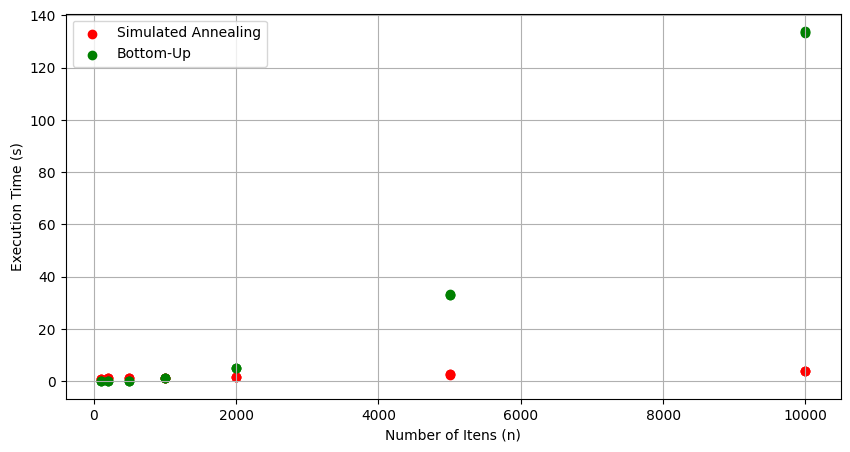

In [29]:
# Plot exec times
plt.figure(figsize=(10, 5))
colors = ['r', 'g', 'm', 'b'] 

for (method_name, method_times), color in zip(times.items(), colors):
    plt.scatter(n_values, method_times, marker='o', linestyle='-', color=color, label=method_name)

plt.xlabel("Number of Itens (n)")
plt.ylabel("Execution Time (s)")
plt.legend()
plt.grid(True)
plt.show()

<div style="background-color:#f0f8ff; color:#333333; padding:10px; border-radius:8px; font-family:Arial, sans-serif; line-height:1.6;">
  <p>
    Applying an adjustment to the neighbor exploration function greatly improved the result. For larger problems, a greater number of items is swapped during each iteration, allowing for better exploration of the available items. We can see that this brought the estimated values much closer to the expected optimal result, with no significant impact on execution time.
  </p>
</div>